# ResNet50 Multi-Label Classification for Dental Images

Train ResNet50 to classify dental issues in images using the classification-dataset on Google Colab with GPU acceleration.

## Cell 1: Install Dependencies

In [12]:
# Install required packages
!pip install -q torch torchvision pillow scikit-learn matplotlib seaborn tqdm

import torch
import torchvision
import numpy as np
import os
from pathlib import Path
import shutil
import json
from datetime import datetime

print("✓ Dependencies installed")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ Dependencies installed
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


## Cell 2: Mount Google Drive

In [13]:
# Mount Google Drive (ONLY for Colab users)
try:
    from google.colab import drive
    print("📂 Mounting Google Drive...")
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
    print("\nYour Drive location: /content/drive/MyDrive")
except:
    print("ℹ Not in Google Colab or Drive already mounted")

📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted

Your Drive location: /content/drive/MyDrive


## Cell 3: Configure Paths

In [14]:
# ===== CONFIGURATION =====
print("🔧 Configuring paths...\n")

DRIVE_PATH = "/content/drive/MyDrive"
PROJECT_FOLDER = "smart-dental-ai"
BASE_DIR = os.path.join(DRIVE_PATH, PROJECT_FOLDER)
DATASET_DIR = os.path.join(BASE_DIR, "datasets")
CLASSIFICATION_DATASET = os.path.join(DATASET_DIR, "classification-dataset")

OUTPUT_DIR = os.path.join(BASE_DIR, "runs/classification-results")
MODEL_SAVE_DIR = os.path.join(OUTPUT_DIR, "models")

print(f"📁 Dataset folder: {CLASSIFICATION_DATASET}")
print(f"📁 Output: {OUTPUT_DIR}\n")

# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

🔧 Configuring paths...

📁 Dataset folder: /content/drive/MyDrive/smart-dental-ai/datasets/classification-dataset
📁 Output: /content/drive/MyDrive/smart-dental-ai/runs/classification-results



## Cell 4: Verify Pre-Split Dataset

Uses the dataset already organized by `split_dataset.py` script.

If running locally: Make sure `data_split/` folder exists in your workspace  
If running on Colab: Make sure `data_split/` folder exists in your Google Drive

In [15]:
print("✓ Using pre-split dataset\n")

# Verify split dataset exists
if os.path.exists(CLASSIFICATION_DATASET):
    print(f"✓ Split dataset found at: {CLASSIFICATION_DATASET}\n")

    train_path = os.path.join(CLASSIFICATION_DATASET, 'train')
    val_path = os.path.join(CLASSIFICATION_DATASET, 'val')

    # Count images in each class
    print("📊 Dataset Structure:")
    train_total = 0
    val_total = 0

    if os.path.exists(train_path):
        classes_in_data = [d for d in os.listdir(train_path)
                          if os.path.isdir(os.path.join(train_path, d))]

        for cls in sorted(classes_in_data):
            train_count = len([f for f in os.listdir(os.path.join(train_path, cls))
                             if os.path.isfile(os.path.join(train_path, cls, f))])
            val_count = len([f for f in os.listdir(os.path.join(val_path, cls))
                            if os.path.isfile(os.path.join(val_path, cls, f))])
            train_total += train_count
            val_total += val_count
            print(f"  {cls:25} {train_count:5} train, {val_count:5} val")

    print(f"\n  {'TOTAL':25} {train_total:5} train, {val_total:5} val")
    print(f"\n✓ Split ratio: {100*train_total/(train_total+val_total):.1f}% train, {100*val_total/(train_total+val_total):.1f}% val")

    # Load class mapping if available
    class_mapping_file = os.path.join(CLASSIFICATION_DATASET, 'class_mapping.json')
    if os.path.exists(class_mapping_file):
        with open(class_mapping_file, 'r') as f:
            CLASS_NAMES = json.load(f)
        print(f"✓ Class mapping loaded from: {class_mapping_file}")
    else:
        print(f"⚠ class_mapping.json not found, using default mapping")
        CLASS_NAMES = {
            'Calculus': 0,
            'Caries': 1,
            'Discoloration': 2,
            'Gingivitis': 3,
            'Hypodontia': 4,
            'Ulcer': 5
        }
else:
    print(f"❌ Split dataset NOT found at: {CLASSIFICATION_DATASET}")
    print(f"\n📝 Run the split script first:")
    print(f"  python split_dataset.py datasets/classification-dataset")
    print(f"\n  Or provide the correct path in Cell 3")

✓ Using pre-split dataset

✓ Split dataset found at: /content/drive/MyDrive/smart-dental-ai/datasets/classification-dataset

📊 Dataset Structure:
  Calculus                   1036 train,   260 val
  Caries                     1874 train,   469 val
  Discoloration              1467 train,   367 val
  Gingivitis                 1879 train,   470 val
  Hypodontia                 1000 train,   251 val
  Ulcer                      2032 train,   509 val

  TOTAL                      9288 train,  2326 val

✓ Split ratio: 80.0% train, 20.0% val
✓ Class mapping loaded from: /content/drive/MyDrive/smart-dental-ai/datasets/classification-dataset/class_mapping.json


## Cell 5: Data Loading with Augmentation

In [17]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn

print("📊 Setting up data loaders...\n")

# Image size for ResNet50
IMG_SIZE = 224
BATCH_SIZE = 16  # Reduced for faster training
NUM_WORKERS = 4  # Parallel data loading for better performance

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet stats
        std=[0.229, 0.224, 0.225]
    )
])

# No augmentation for validation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Paths to pre-split data
train_path = os.path.join(CLASSIFICATION_DATASET, 'train')
val_path = os.path.join(CLASSIFICATION_DATASET, 'val')

print(f"Loading from:")
print(f"  Train: {train_path}")
print(f"  Val: {val_path}\n")

# Load datasets from pre-split folders
train_dataset = ImageFolder(train_path, transform=train_transform)
val_dataset = ImageFolder(val_path, transform=val_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# Get class info
classes = train_dataset.classes
num_classes = len(classes)

print(f"✓ Data loaders created")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Number of classes: {num_classes}")
print(f"  Classes: {sorted(classes)}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"\n  Training batches per epoch: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

📊 Setting up data loaders...

Loading from:
  Train: /content/drive/MyDrive/smart-dental-ai/datasets/classification-dataset/train
  Val: /content/drive/MyDrive/smart-dental-ai/datasets/classification-dataset/val

✓ Data loaders created
  Training samples: 9288
  Validation samples: 2326
  Number of classes: 6
  Classes: ['Calculus', 'Caries', 'Discoloration', 'Gingivitis', 'Hypodontia', 'Ulcer']
  Batch size: 16
  Image size: 224x224

  Training batches per epoch: 581
  Validation batches: 146


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Cell 6: Load ResNet50 Model

In [18]:
from torchvision.models import resnet50, ResNet50_Weights

print("🔧 Loading ResNet50 model...\n")

# Load pretrained ResNet50 (transfer learning)
weights = ResNet50_Weights.IMAGENET1K_V1
model = resnet50(weights=weights)

print("✓ ResNet50 loaded with ImageNet pretrained weights")

# Freeze backbone layers
for param in model.parameters():
    param.requires_grad = False

print("✓ Backbone frozen (will only train classifier head)")

# Replace classification head
model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, num_classes)
)

print(f"✓ Classification head replaced (output: {num_classes} classes)")

# Enable gradients for new head
for param in model.fc.parameters():
    param.requires_grad = True

print(f"\n📊 Model Info:")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

🔧 Loading ResNet50 model...

✓ ResNet50 loaded with ImageNet pretrained weights
✓ Backbone frozen (will only train classifier head)
✓ Classification head replaced (output: 6 classes)

📊 Model Info:
  Total parameters: 24,623,558
  Trainable parameters: 1,115,526


## Cell 7: Training Loop

In [20]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
from tqdm import tqdm

print("🚀 Starting Training\n")

# Setup training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

NUM_EPOCHS = 15  # Reduced for faster training (increase to 30 for final)
best_val_acc = 0
best_model_path = os.path.join(MODEL_SAVE_DIR, 'best_model.pth')

training_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

def train_epoch(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Training", leave=False)
    for batch_idx, (images, labels) in enumerate(pbar):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar with current metrics
        batch_acc = 100.0 * (correct / total)
        pbar.set_postfix({'Loss': f'{running_loss/(batch_idx+1):.4f}', 'Acc': f'{batch_acc:.2f}%'})

    avg_loss = running_loss / len(train_loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

def validate_epoch():
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(val_loader, desc=f"Validating", leave=False)
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Update progress bar
            batch_acc = 100.0 * (correct / total)
            pbar.set_postfix({'Loss': f'{running_loss/(len(val_loader) if total > 0 else 1):.4f}', 'Acc': f'{batch_acc:.2f}%'})

    avg_loss = running_loss / len(val_loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

# Training loop
start_time = time.time()
no_improve_count = 0
print(f"Training on device: {device}\n")

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    print(f"📈 Epoch {epoch + 1}/{NUM_EPOCHS}")

    # Train
    train_loss, train_acc = train_epoch(epoch)
    training_history['train_loss'].append(train_loss)
    training_history['train_acc'].append(train_acc)

    # Validate
    val_loss, val_acc = validate_epoch()
    training_history['val_loss'].append(val_loss)
    training_history['val_acc'].append(val_acc)

    epoch_time = time.time() - epoch_start_time

    # Summary
    print(f"  ✓ Completed in {epoch_time:.1f}s")
    print(f"    Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
    print(f"    Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"    ✓ Best model saved!")
        no_improve_count = 0
    else:
        no_improve_count += 1
        print(f"    (No improvement for {no_improve_count} epoch(s))")

    # Early stopping if no improvement
    if no_improve_count >= 5:
        print(f"\n⏹ Early stopping: No improvement for {no_improve_count} epochs")
        break

    # Learning rate scheduling
    scheduler.step(val_loss)

elapsed_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"✅ Training completed!")
print(f"   Total time: {elapsed_time/60:.1f} minutes ({elapsed_time/3600:.2f} hours)")
print(f"   Best validation accuracy: {best_val_acc:.2f}%")
print(f"   Model saved to: {best_model_path}")
print(f"{'='*60}")

🚀 Starting Training

Training on device: cuda

📈 Epoch 1/15


Training:   0%|          | 0/581 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  ✓ Completed in 970.2s
    Train: Loss=1.2296, Acc=49.24%
    Val:   Loss=0.8503, Acc=64.23%
    ✓ Best model saved!
📈 Epoch 2/15


  ✓ Completed in 105.0s
    Train: Loss=0.9986, Acc=59.72%
    Val:   Loss=0.7615, Acc=65.95%
    ✓ Best model saved!
📈 Epoch 3/15


  ✓ Completed in 103.7s
    Train: Loss=0.9573, Acc=61.90%
    Val:   Loss=0.7433, Acc=69.91%
    ✓ Best model saved!
📈 Epoch 4/15


...

  ✓ Completed in 102.2s
    Train: Loss=0.8562, Acc=66.51%
    Val:   Loss=0.6765, Acc=71.80%
    (No improvement for 1 epoch(s))
📈 Epoch 8/15


  ✓ Completed in 100.2s
    Train: Loss=0.8332, Acc=66.90%
    Val:   Loss=0.6183, Acc=73.04%
    (No improvement for 2 epoch(s))
📈 Epoch 9/15


  ✓ Completed in 103.6s
    Train: Loss=0.8368, Acc=66.77%
    Val:   Loss=0.6140, Acc=75.37%
    (No improvement for 3 epoch(s))
📈 Epoch 10/15


  ✓ Completed in 104.9s
    Train: Loss=0.7980, Acc=68.10%
    Val:   Loss=0.7162, Acc=70.25%
    (No improvement for 4 epoch(s))
📈 Epoch 11/15


  ✓ Completed in 103.5s
    Train: Loss=0.7941, Acc=68.60%
    Val:   Loss=0.6255, Acc=75.02%
    (No improvement for 5 epoch(s))

⏹ Early stopping: No improvement for 5 epochs

✅ Training completed!
   Total time: 33.6 minutes (0.56 hours)
   Best validation accuracy: 75.49%
   Model saved to: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/models/best_model.pth


## Cell 7b: Continue Training (Optional To Improve accuracy- :After Initial Training)

In [31]:
print("🚀 Enhanced Training: Focal Loss + Fine-tuning\n")

# ===== FOCAL LOSS FOR CLASS IMBALANCE =====
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        p_t = torch.exp(-ce_loss)
        loss = (1 - p_t) ** self.gamma * ce_loss
        return loss.mean()

# ===== CALCULATE CLASS WEIGHTS =====
print("📊 Computing class weights...\n")
class_counts = {}
for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
    class_counts[class_name] = count

total_samples = sum(class_counts.values())
class_weights = {}
for class_name, count in class_counts.items():
    weight = total_samples / (num_classes * count)
    class_weights[class_name] = weight

print("Class Weights:")
for c in sorted(classes):
    print(f"  {c:15} {class_weights[c]:.3f}")

weights_tensor = torch.tensor([class_weights[c] for c in classes], dtype=torch.float32).to(device)
print()

# ===== ENHANCED AUGMENTATION =====
print("🎨 Setting up enhanced augmentation...\n")
enhanced_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.6),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=25),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_enhanced = ImageFolder(train_path, transform=enhanced_train_transform)
train_loader_enhanced = DataLoader(train_dataset_enhanced, batch_size=BATCH_SIZE, shuffle=True,
                                    num_workers=NUM_WORKERS, pin_memory=True)

# ===== LOAD & PREPARE MODEL =====
print("✓ Enhanced augmentation ready")
print("✓ Loading best model...\n")

model.load_state_dict(torch.load(best_model_path))
best_val_acc_enhanced = best_val_acc

# Unfreeze backbone layer 4 for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True

print("✓ Unfrozen ResNet50 Layer 4 for fine-tuning")

# Focal Loss with class weights
criterion_enhanced = FocalLoss(alpha=weights_tensor, gamma=2.0)

# Differential learning rates
optimizer_enhanced = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 0.0001},
    {'params': model.fc.parameters(), 'lr': 0.001}
], weight_decay=1e-4)

scheduler_enhanced = ReduceLROnPlateau(optimizer_enhanced, mode='min', factor=0.3, patience=3)

ADDITIONAL_EPOCHS = 40
no_improve_count = 0
start_time = time.time()
start_epoch = len(training_history['train_loss'])

print(f"Loss: Focal Loss (γ=2.0)")
print(f"Optimizer: Adam with differential LR (backbone: 1e-4, head: 1e-3)")
print(f"Epochs: {ADDITIONAL_EPOCHS}\n")

# ===== TRAINING LOOP =====
for epoch in range(ADDITIONAL_EPOCHS):
    epoch_start_time = time.time()
    current_epoch = start_epoch + epoch + 1
    print(f"📈 Epoch {current_epoch}/{start_epoch + ADDITIONAL_EPOCHS}")

    # Train phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader_enhanced, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_enhanced.zero_grad()
        outputs = model(images)
        loss = criterion_enhanced(outputs, labels)
        loss.backward()
        optimizer_enhanced.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader_enhanced)
    train_acc = 100.0 * correct / total
    training_history['train_loss'].append(train_loss)
    training_history['train_acc'].append(train_acc)

    # Validate phase
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(val_loader, desc="Validating", leave=False)
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion_enhanced(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(val_loader)
    val_acc = 100.0 * correct / total
    training_history['val_loss'].append(val_loss)
    training_history['val_acc'].append(val_acc)

    epoch_time = time.time() - epoch_start_time

    # Summary
    print(f"  ✓ {epoch_time:.1f}s | Train: {train_loss:.4f}, {train_acc:.2f}% | Val: {val_loss:.4f}, {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc_enhanced:
        best_val_acc_enhanced = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"    ✓ Best model improved to {val_acc:.2f}%!")
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count > 1:
            print(f"    (No improvement for {no_improve_count} epochs)")

    # Early stopping
    if no_improve_count >= 7:
        print(f"\n⏹ Early stopping: No improvement for 7 epochs")
        break

    scheduler_enhanced.step(val_loss)

elapsed_time = time.time() - start_time
epochs_completed = epoch + 1

print(f"\n{'='*60}")
print(f"✅ Enhanced training completed!")
print(f"   Epochs run: {epochs_completed}/{ADDITIONAL_EPOCHS}")
print(f"   Total epochs: {len(training_history['train_loss'])}")
print(f"   Time: {elapsed_time/60:.1f} min ({elapsed_time/3600:.2f}h)")
print(f"   Before: {best_val_acc:.2f}% → After: {best_val_acc_enhanced:.2f}%")
print(f"   Improvement: {best_val_acc_enhanced - best_val_acc:+.2f}%")
print(f"{'='*60}")

🚀 Enhanced Training: Focal Loss + Fine-tuning

📊 Computing class weights...

Class Weights:
  Calculus        1.494
  Caries          0.826
  Discoloration   1.055
  Gingivitis      0.824
  Hypodontia      1.548
  Ulcer           0.762

🎨 Setting up enhanced augmentation...

✓ Enhanced augmentation ready
✓ Loading best model...

✓ Unfrozen ResNet50 Layer 4 for fine-tuning
Loss: Focal Loss (γ=2.0)
Optimizer: Adam with differential LR (backbone: 1e-4, head: 1e-3)
Epochs: 40

📈 Epoch 29/68


  ✓ 160.9s | Train: 0.5237, 60.10% | Val: 0.2817, 65.22%
📈 Epoch 30/68


  ✓ 146.4s | Train: 0.3711, 66.28% | Val: 0.2380, 69.17%
    (No improvement for 2 epochs)
📈 Epoch 31/68


  ✓ 144.2s | Train: 0.2979, 69.84% | Val: 0.1956, 82.33%
    ✓ Best model improved to 82.33%!
📈 Epoch 32/68


  ✓ 148.1s | Train: 0.2684, 72.47% | Val: 0.2798, 74.89%
📈 Epoch 33/68


...

  ✓ 151.3s | Train: 0.0681, 89.67% | Val: 0.0732, 90.93%
    (No improvement for 3 epochs)
📈 Epoch 59/68


  ✓ 155.6s | Train: 0.0634, 90.17% | Val: 0.0704, 90.33%
    (No improvement for 4 epochs)
📈 Epoch 60/68


  ✓ 152.3s | Train: 0.0629, 90.05% | Val: 0.0827, 90.03%
    (No improvement for 5 epochs)
📈 Epoch 61/68


  ✓ 147.6s | Train: 0.0613, 90.75% | Val: 0.0783, 90.63%
    (No improvement for 6 epochs)
📈 Epoch 62/68


  ✓ 145.4s | Train: 0.0636, 90.19% | Val: 0.0914, 89.12%
    (No improvement for 7 epochs)

⏹ Early stopping: No improvement for 7 epochs

✅ Enhanced training completed!
   Epochs run: 34/40
   Total epochs: 62
   Time: 84.5 min (1.41h)
   Before: 78.37% → After: 91.06%
   Improvement: +12.68%


## Cell 8: Plot Training History

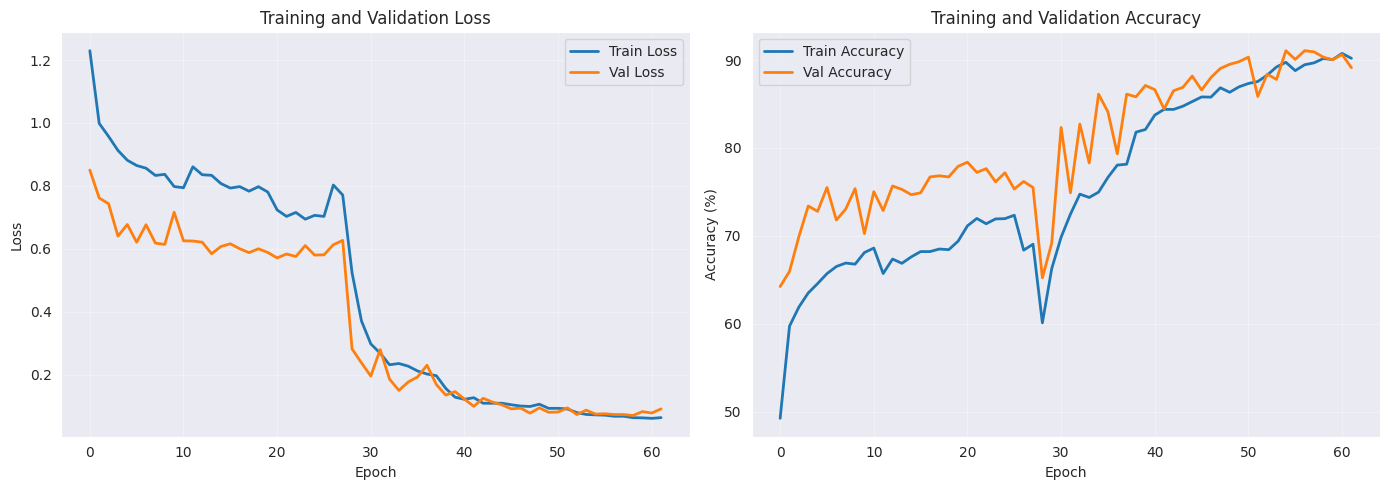

✓ Plot saved to: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/training_history.png


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(training_history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(training_history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(training_history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(training_history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved to: {os.path.join(OUTPUT_DIR, 'training_history.png')}")

## Cell 9: Final Evaluation

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print("📊 Final Evaluation\n")

# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Collect predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Print metrics
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix saved to: ", os.path.join(OUTPUT_DIR, 'confusion_matrix.npy'))
np.save(os.path.join(OUTPUT_DIR, 'confusion_matrix.npy'), cm)

📊 Final Evaluation

Classification Report:
               precision    recall  f1-score   support

     Calculus       0.61      0.91      0.73       260
       Caries       0.99      0.97      0.98       469
Discoloration       0.95      1.00      0.97       367
   Gingivitis       0.91      0.69      0.79       470
   Hypodontia       1.00      0.92      0.96       251
        Ulcer       1.00      1.00      1.00       509

     accuracy                           0.91      2326
    macro avg       0.91      0.91      0.90      2326
 weighted avg       0.93      0.91      0.91      2326


Confusion Matrix saved to:  /content/drive/MyDrive/smart-dental-ai/runs/classification-results/confusion_matrix.npy


📊 Plotting Confusion Matrix



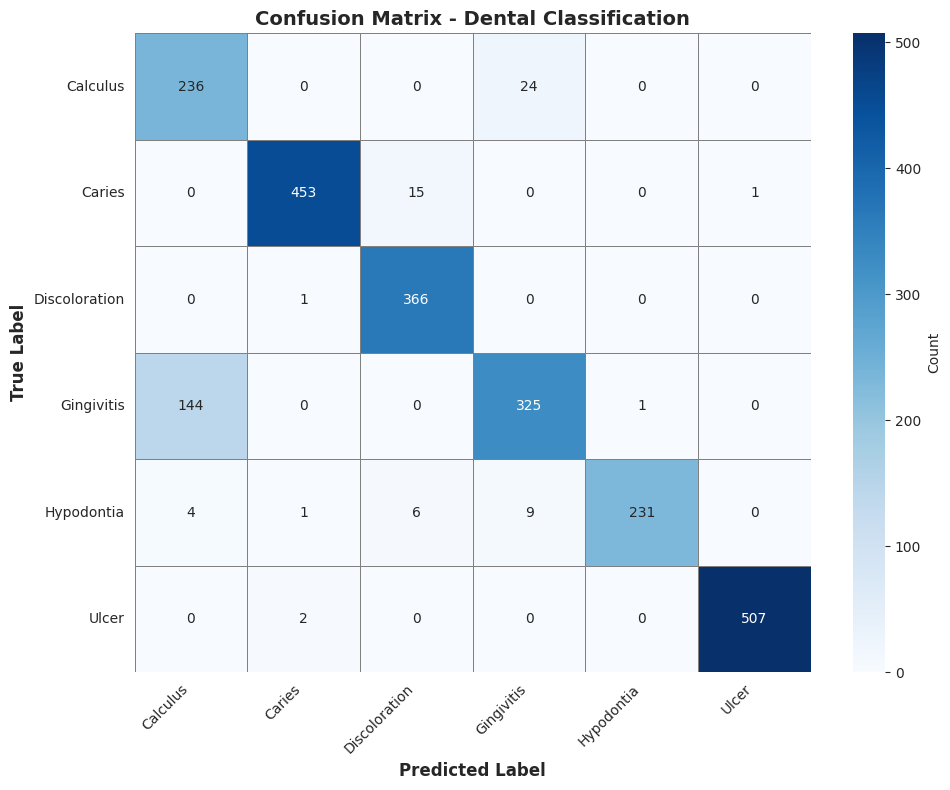

✓ Confusion matrix saved to: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/confusion_matrix.png

Per-class Accuracy (Recall):
  Calculus         90.8% (236/260)
  Caries           96.6% (453/469)
  Discoloration    99.7% (366/367)
  Gingivitis       69.1% (325/470)
  Hypodontia       92.0% (231/251)
  Ulcer            99.6% (507/509)


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Plotting Confusion Matrix\n")

# Load confusion matrix
cm = np.load(os.path.join(OUTPUT_DIR, 'confusion_matrix.npy'))

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'},
            ax=ax, linewidths=0.5, linecolor='gray')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Dental Classification', fontsize=14, fontweight='bold')

# Rotate labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Confusion matrix saved to: {os.path.join(OUTPUT_DIR, 'confusion_matrix.png')}")

# Print per-class accuracy
print("\nPer-class Accuracy (Recall):")
for i, class_name in enumerate(classes):
    total = cm[i].sum()
    correct = cm[i, i]
    accuracy = 100.0 * correct / total if total > 0 else 0
    print(f"  {class_name:15} {accuracy:5.1f}% ({correct}/{total})")

## Cell 10: Inference on Single Image

🧪 Testing inference on validation images



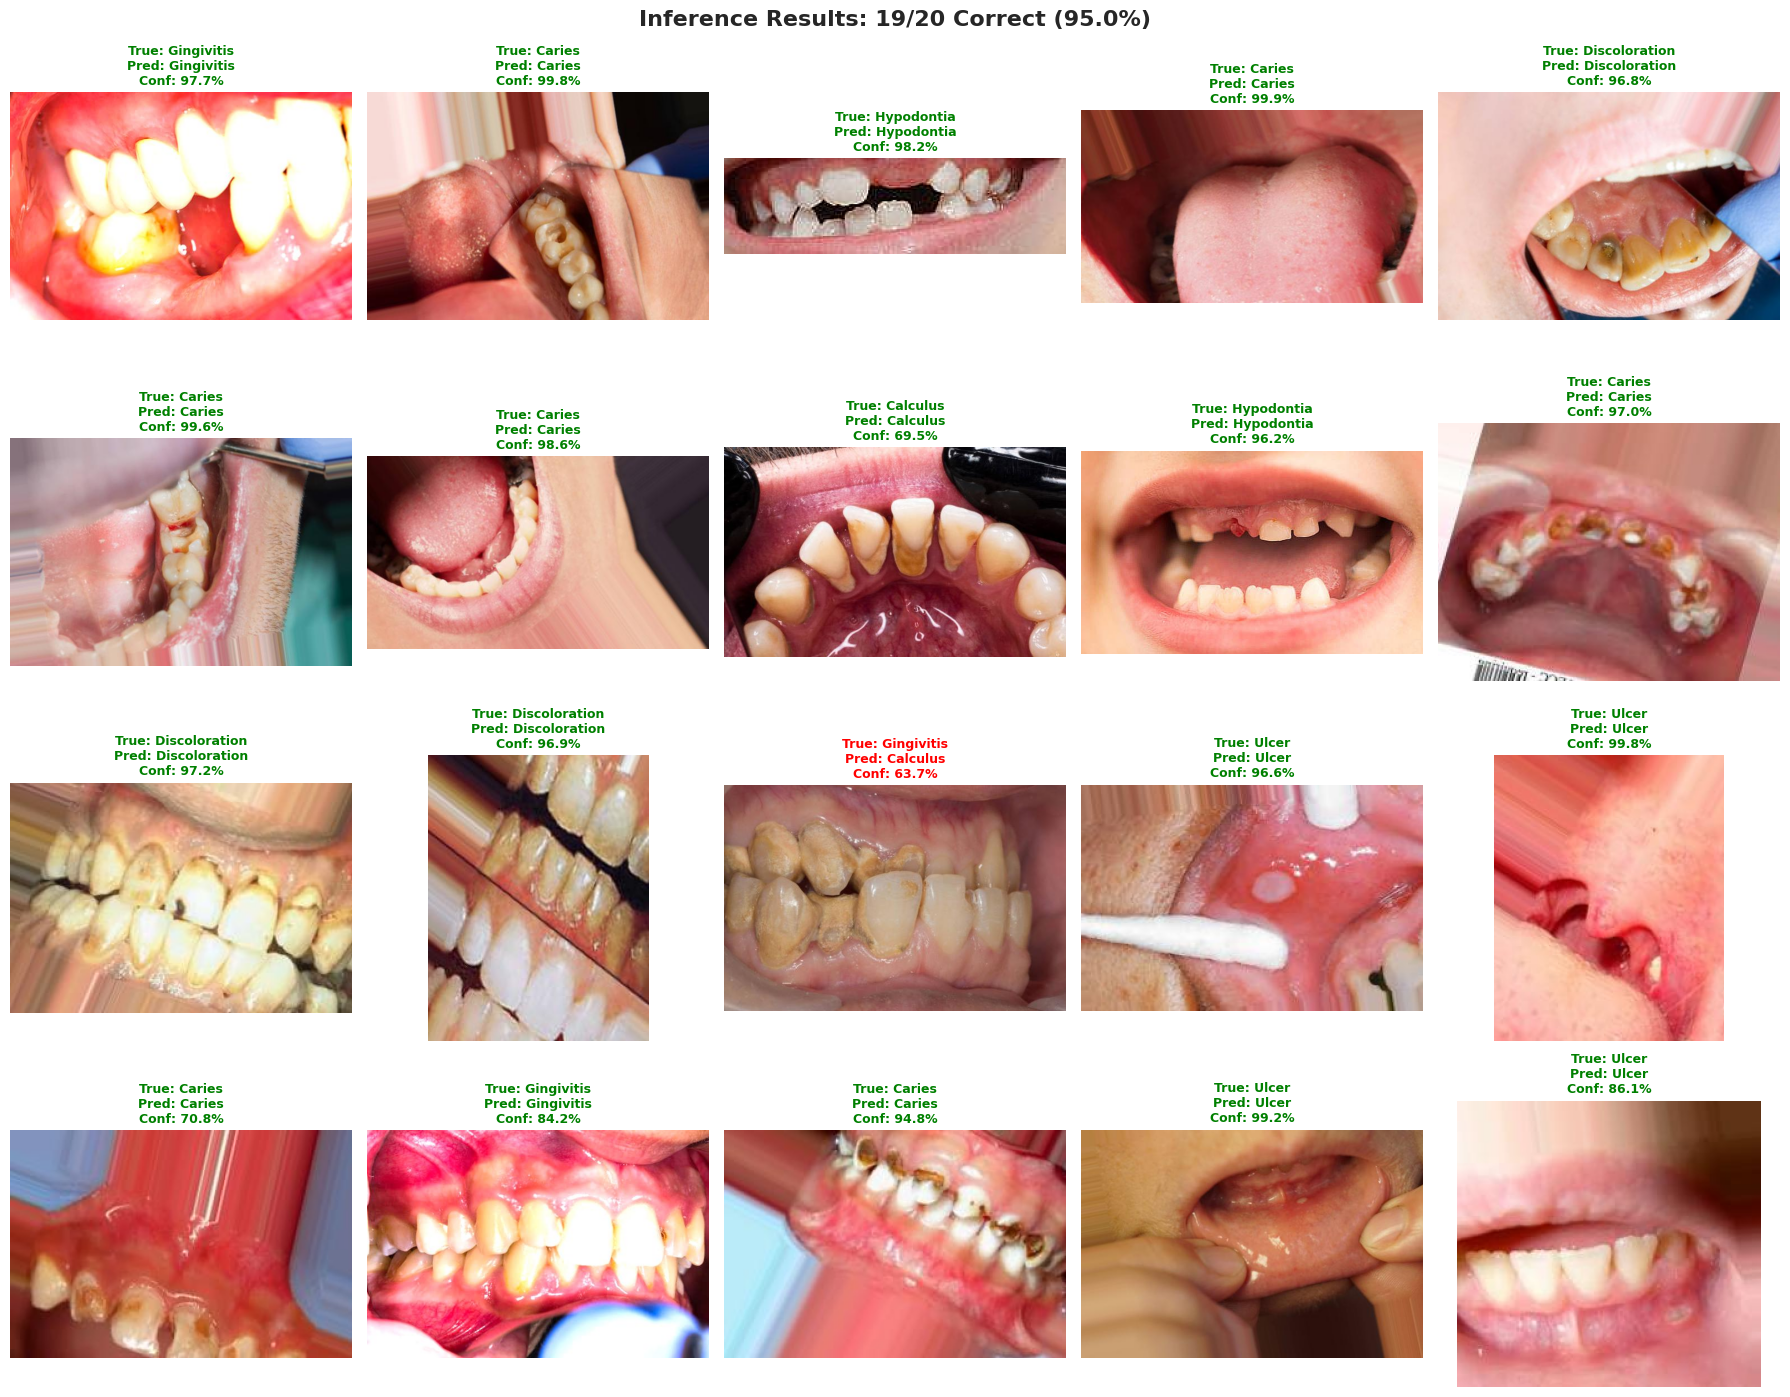

✓ Inference examples saved to: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/inference_examples.png

Inference Summary (20 images)
Accuracy: 95.0% (19/20)

Detailed Predictions:
  ✓ Image 1: Gingivitis      → Gingivitis      (97.7%)
  ✓ Image 2: Caries          → Caries          (99.8%)
  ✓ Image 3: Hypodontia      → Hypodontia      (98.2%)
  ✓ Image 4: Caries          → Caries          (99.9%)
  ✓ Image 5: Discoloration   → Discoloration   (96.8%)
  ✓ Image 6: Caries          → Caries          (99.6%)
  ✓ Image 7: Caries          → Caries          (98.6%)
  ✓ Image 8: Calculus        → Calculus        (69.5%)
  ✓ Image 9: Hypodontia      → Hypodontia      (96.2%)
  ✓ Image 10: Caries          → Caries          (97.0%)
  ✓ Image 11: Discoloration   → Discoloration   (97.2%)
  ✓ Image 12: Discoloration   → Discoloration   (96.9%)
  ✗ Image 13: Gingivitis      → Calculus        (63.7%)
  ✓ Image 14: Ulcer           → Ulcer           (96.6%)
  ✓ Image 15: Ulcer       

In [40]:
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("🧪 Testing inference on validation images\n")

# Get random validation images
num_images = 20
val_images_paths = list(val_dataset.imgs)
import random
random.shuffle(val_images_paths)
val_images_paths = val_images_paths[:num_images]

# Create grid layout
rows, cols = 4, 5
fig, axes = plt.subplots(rows, cols, figsize=(18, 14))
axes = axes.flatten()

correct = 0
total = 0
predictions_data = []

model.eval()
for idx, (img_path, label_idx) in enumerate(val_images_paths):
    # Load image
    image = PILImage.open(img_path).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_class = probabilities.argmax(1).item()
        confidence = probabilities[0, predicted_class].item()

    true_label = classes[label_idx]
    pred_label = classes[predicted_class]
    is_correct = predicted_class == label_idx

    # Update stats
    correct += int(is_correct)
    total += 1
    predictions_data.append({
        'true': true_label,
        'pred': pred_label,
        'confidence': confidence,
        'correct': is_correct
    })

    # Display
    ax = axes[idx]
    ax.imshow(image)

    # Color border: green for correct, red for incorrect
    border_color = 'green' if is_correct else 'red'
    border_width = 3
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(border_width)

    # Title with color
    title_color = 'green' if is_correct else 'red'
    title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1%}"
    ax.set_title(title, fontsize=9, fontweight='bold', color=title_color)
    ax.axis('off')

plt.suptitle(f'Inference Results: {correct}/{total} Correct ({100*correct/total:.1f}%)',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'inference_examples.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"✓ Inference examples saved to: {os.path.join(OUTPUT_DIR, 'inference_examples.png')}")
print(f"\n{'='*50}")
print(f"Inference Summary ({num_images} images)")
print(f"{'='*50}")
print(f"Accuracy: {100*correct/total:.1f}% ({correct}/{total})")
print(f"\nDetailed Predictions:")
for i, pred in enumerate(predictions_data, 1):
    status = "✓" if pred['correct'] else "✗"
    print(f"  {status} Image {i}: {pred['true']:15} → {pred['pred']:15} ({pred['confidence']:.1%})")
print(f"{'='*50}")

## Cell 11: Save Model and Info

In [36]:
print("💾 Saving trained model\n")

# Save model weights
final_model_path = os.path.join(MODEL_SAVE_DIR, 'resnet50_dental_classifier.pth')
torch.save(model.state_dict(), final_model_path)
print(f"✓ Model weights saved: {final_model_path}")

# Save complete model (architecture + weights)
torch.save(model, os.path.join(MODEL_SAVE_DIR, 'resnet50_dental_classifier_full.pth'))
print(f"✓ Full model saved")

# Save training metadata
metadata = {
    'model': 'ResNet50',
    'num_classes': num_classes,
    'classes': classes,
    'image_size': IMG_SIZE,
    'best_validation_accuracy': best_val_acc,
    'training_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'timestamp': datetime.now().isoformat()
}

meta_file = os.path.join(MODEL_SAVE_DIR, 'model_metadata.json')
with open(meta_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved: {meta_file}")

# Save training history
history_file = os.path.join(OUTPUT_DIR, 'training_history.json')
with open(history_file, 'w') as f:
    json.dump(training_history, f)

print(f"✓ Training history saved: {history_file}")

# Summary
print(f"\n📦 Model Package Ready!")
print(f"\n📁 Location: {MODEL_SAVE_DIR}")
print(f"  - resnet50_dental_classifier.pth (weights only) [~105 MB]")
print(f"  - resnet50_dental_classifier_full.pth (full model)")
print(f"  - model_metadata.json (training info)")
print(f"\n✅ Best Validation Accuracy: {best_val_acc:.2f}%")

💾 Saving trained model

✓ Model weights saved: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/models/resnet50_dental_classifier.pth
✓ Full model saved
✓ Metadata saved: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/models/model_metadata.json
✓ Training history saved: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/training_history.json

📦 Model Package Ready!

📁 Location: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/models
  - resnet50_dental_classifier.pth (weights only) [~105 MB]
  - resnet50_dental_classifier_full.pth (full model)
  - model_metadata.json (training info)

✅ Best Validation Accuracy: 78.37%
